In [1]:
from pathlib import Path
import numpy as np
from feature import make_stft_extractor
from test_vectorized import (
    merge_consecutive_detections, run_detection_pipeline_new,
    load_all_template_features_new, load_all_thresholds_new,
    read_audio_chunk, plot_pr_curve, load_raven_selection_table,
    compute_pr_curve, compute_average_precision, match_detections,
    plot_detection_spectrograms, get_exclusion_intervals, get_exclusion_mask,
)


DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
THRESHOLDS = RESULTS / "Thresholds"

n_temps = 5
extractor = make_stft_extractor()

In [2]:
st_feats, mt_feats, bt_feats = load_all_template_features_new(
    results_dir=RESULTS_29,
    file_label="20230429_Templates",
    recording_label="20230429_102841",
    extractor=extractor,
    n_templates=n_temps,
    fs_new=1000,
)

Load thresholds

In [3]:
st_threshold, mt_threshold, bt_threshold = load_all_thresholds_new(
    results_dir=THRESHOLDS,
    file_label="5_Templates",          # matches what your calibration loop saved
    extractor=extractor,
)

print(f"Single Tone Threshold: {st_threshold}")
print(f"Multi Tone Threshold: {mt_threshold}")
print(f"Burst Tonal Threshold: {bt_threshold}")

Single Tone Threshold: 0.13963193597699997
Multi Tone Threshold: 0.13811596130726883
Burst Tonal Threshold: 0.14674281582162435


Load 72 hour audio in 1 hour segments

In [4]:
ground_truth = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
td_intervals = get_exclusion_intervals(ground_truth, exclude_labels=("td",), pad=0.1)

all_detected_t, all_detected_labels, all_scores, all_labels_all, all_times_all = run_detection_pipeline_new(
    audio_file=DATA_22 / "20230422_171301.wav",
    n_hours=72,
    st_feats=st_feats, mt_feats=mt_feats, bt_feats=bt_feats,
    st_threshold=st_threshold, mt_threshold=mt_threshold, bt_threshold=bt_threshold,
    exclude_intervals=td_intervals,
    extractor=extractor,
)

Processing hour 1 of 72: 26 / 47999 windows flagged as calls
Processing hour 2 of 72: 3 / 47999 windows flagged as calls
Processing hour 3 of 72: 3 / 47999 windows flagged as calls
Processing hour 4 of 72: 1 / 47999 windows flagged as calls
Processing hour 5 of 72: 1 / 47999 windows flagged as calls
Processing hour 6 of 72: 2 / 47999 windows flagged as calls
Processing hour 7 of 72: 1 / 47999 windows flagged as calls
Processing hour 8 of 72: 1 / 47999 windows flagged as calls
Processing hour 9 of 72: 0 / 47999 windows flagged as calls
Processing hour 10 of 72: 1 / 47999 windows flagged as calls
Processing hour 11 of 72: 3 / 47999 windows flagged as calls
Processing hour 12 of 72: 2 / 47999 windows flagged as calls
Processing hour 13 of 72: 1 / 47999 windows flagged as calls
Processing hour 14 of 72: 15 / 47999 windows flagged as calls
Processing hour 15 of 72: 24 / 47999 windows flagged as calls
Processing hour 16 of 72: 3 / 47999 windows flagged as calls
Processing hour 17 of 72: 9 / 

Merge Consecutive detected windows

In [5]:
combined_calls = merge_consecutive_detections(all_detected_t, all_detected_labels, step=0.075, window_len=0.15)

print(f"Merged {len(all_detected_t)} raw window detections into {len(combined_calls)} calls")

Merged 17668 raw window detections into 5961 calls


PR curve / Ground truthing

In [6]:
ground_truth = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
exclude_labels = ("td",)
ground_truth_eval = [g for g in ground_truth if g["label"] not in exclude_labels]
precision, recall, thresholds = compute_pr_curve(
    all_times_all, all_scores, all_labels_all, ground_truth_eval,
    step=0.075, window_len=0.15, n_thresholds=20, require_label_match=False
)


In [7]:
ap = compute_average_precision(precision, recall)
print(f"Average Precision: {ap:.4f}")

idx = np.argmin(np.abs(thresholds - mt_threshold))
print(f"At your chosen mt_threshold: precision={precision[idx]:.3f}, recall={recall[idx]:.3f}")

tp, fp, fn, false_positive_detections, false_negative_gts = match_detections(combined_calls, ground_truth_eval, require_label_match=False)
precision_point = tp / (tp + fp) if (tp + fp) > 0 else 1.0
recall_point = tp / (tp + fn) if (tp + fn) > 0 else 0.0
print(f"combined_calls: precision={precision_point:.3f}, recall={recall_point:.3f}")

Average Precision: 0.7132
At your chosen mt_threshold: precision=0.255, recall=0.974
combined_calls: precision=0.269, recall=0.978


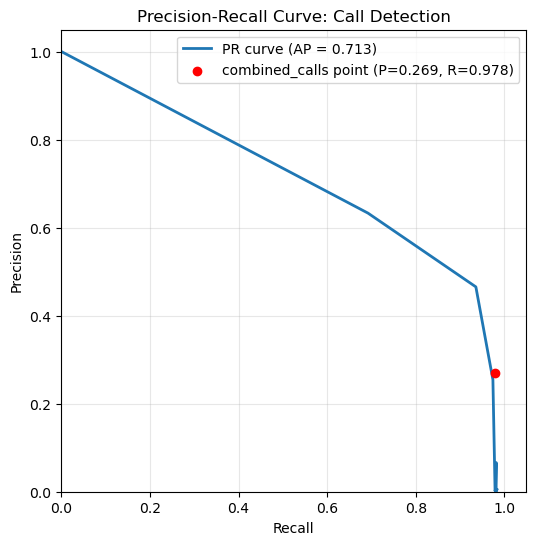

In [8]:
plot_pr_curve(precision, recall, ap=ap, marked_point=(precision_point, recall_point))

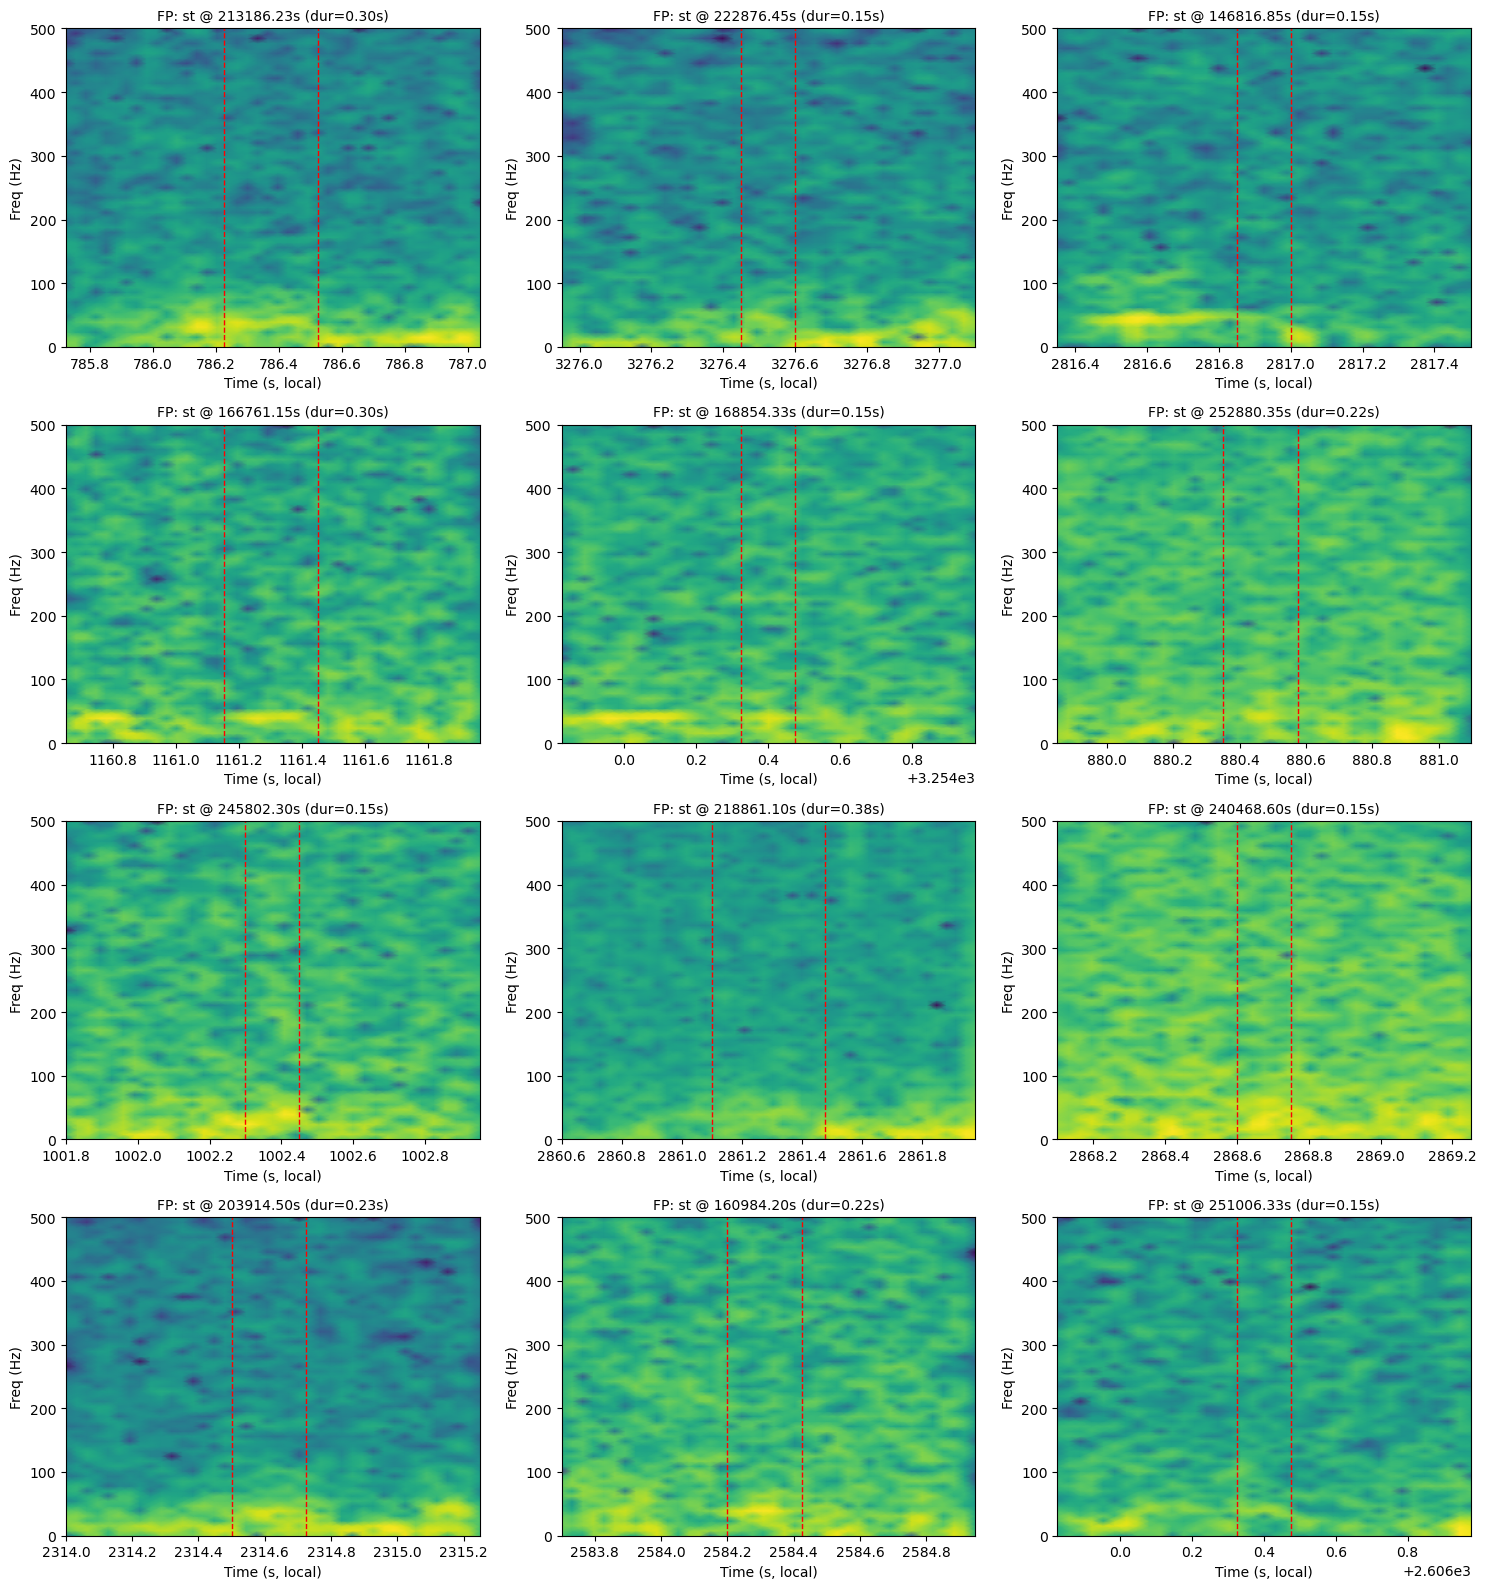

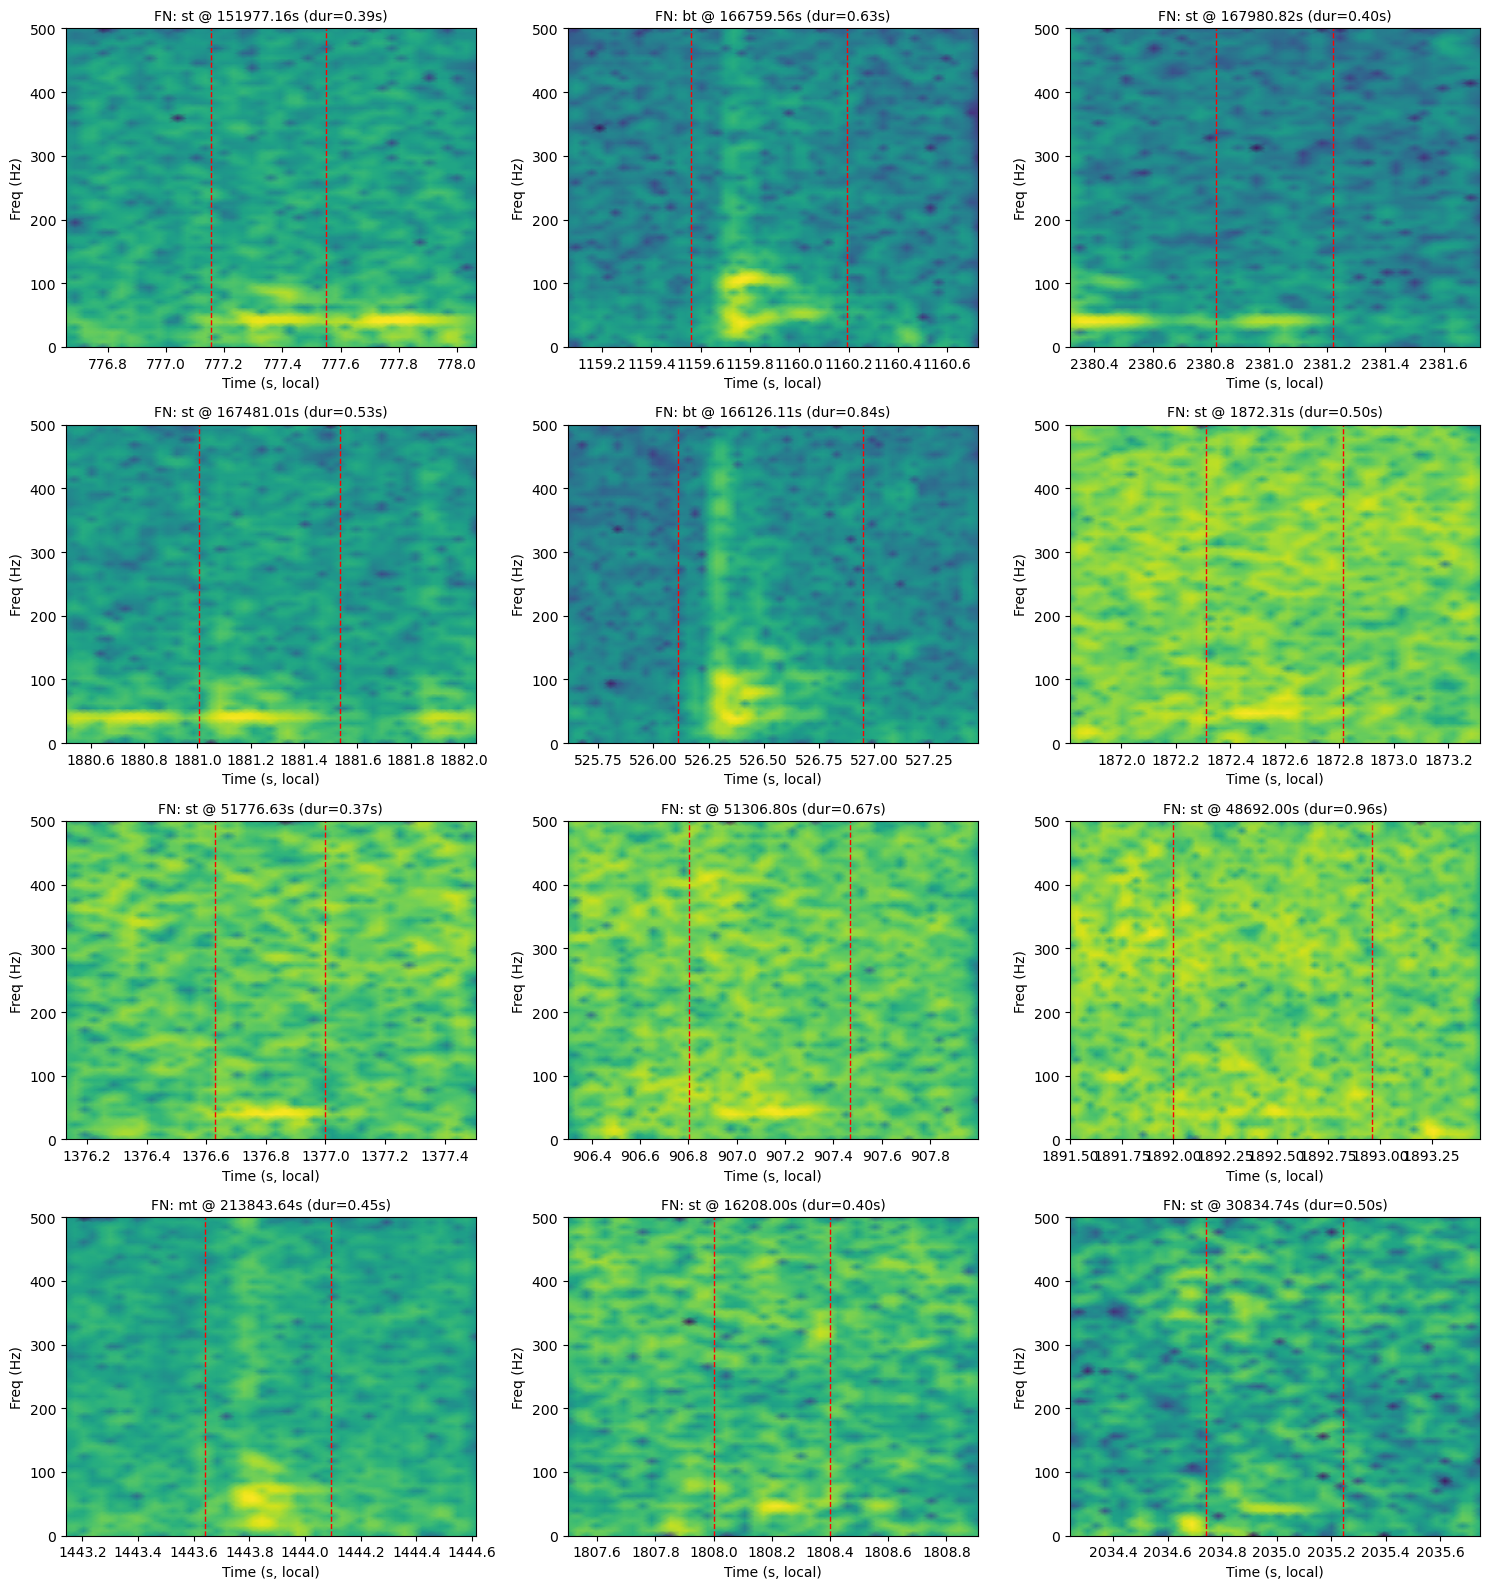

In [9]:
# plot a random sample of false positives
plot_detection_spectrograms(
    false_positive_detections,
    DATA_22 / "20230422_171301.wav",
    fs_new=1000,
    n_examples=12,
    title_prefix="FP"
)

# you can also inspect false negatives (missed calls) the same way
fn_as_tuples = [(g["start"], g["end"], g["label"]) for g in false_negative_gts]
plot_detection_spectrograms(
    fn_as_tuples,
    DATA_22 / "20230422_171301.wav",
    fs_new=1000,
    n_examples=12,
    title_prefix="FN"
)